# Fundamentos de Séries Temporais

### Módulo F1 | Previsão de Demanda na Gestão de Planos de Saúde

**Prof. Pedro** &nbsp;·&nbsp; Mestrado e Doutorado em Simulação

---

Este notebook é o laboratório prático da Seção 2 da apostila. O objetivo não é apenas rodar código, e sim construir a intuição estatística que sustenta todos os modelos de previsão que veremos depois (ARIMA, SARIMA, Prophet, XGBoost, LSTM).

O foco de todo o curso é a **gestão da operadora**, ou seja, a administração do plano de saúde. Vamos trabalhar com um estudo de caso central dessa operação, do começo ao fim: o **volume de ligações recebidas na central de atendimento da operadora**, medido hora a hora. Prever essa demanda é o que permite dimensionar a equipe, reduzir o tempo de espera do beneficiário e controlar o custo operacional. Os mesmos fundamentos valem para as demais séries da operadora: demanda por teleconsulta, sinistralidade mensal e volume de solicitações de autorização prévia.

Toda a base é gerada de forma sintética dentro do próprio notebook, então você pode executar tudo sem depender de nenhum arquivo externo.

**Ao final desta aula você será capaz de:**

1. Explicar o que é uma série temporal e por que a dependência temporal muda tudo.
2. Decompor uma série em tendência, sazonalidade, ciclo e resíduo.
3. Entender e testar a estacionariedade (teste ADF) e por que ela é pré-requisito do ARIMA.
4. Ler os gráficos de ACF e PACF e conectar cada um à identificação de modelos.

**Como usar este material:** execute as células na ordem, de cima para baixo. Após cada gráfico ou tabela há um bloco **Lendo o resultado**, que interpreta o que apareceu, ponto a ponto. Onde houver controles deslizantes (sliders), mova-os e observe o gráfico responder em tempo real.


## 0. Preparação do ambiente

A célula abaixo garante que todas as bibliotecas necessárias estão instaladas e define alguns padrões visuais. Se algo faltar, ela instala automaticamente. Rode uma vez e siga em frente.


In [13]:
import sys, subprocess

def _garantir(pacotes):
    for nome in pacotes:
        try:
            __import__(nome)
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", nome])

_garantir(["numpy", "pandas", "matplotlib", "statsmodels", "ipywidgets"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

SEMENTE = 11
print("Ambiente pronto. Bibliotecas carregadas com sucesso.")


Ambiente pronto. Bibliotecas carregadas com sucesso.


## Nosso laboratório: a central de atendimento da operadora

Antes de estudar os conceitos, precisamos de dados para olhar. Vamos **construir** uma série temporal do volume de ligações recebidas na central de atendimento, hora a hora. Construir em vez de baixar tem uma vantagem didática enorme: como nós mesmos definimos a tendência, a sazonalidade e o ruído, sabemos exatamente o que deveria aparecer quando formos decompor a série. É como montar um relógio para depois abri-lo e reconhecer cada peça.

A função `gerar_serie_ligacoes` combina quatro ingredientes, que são justamente os quatro componentes da Seção 2.2:

- um **nível base** com uma leve **tendência** de crescimento (a carteira de beneficiários aumenta ao longo do tempo, e com ela o volume de contatos);
- um **ciclo diário** de 24 horas (madrugada calma, forte pico em horário comercial, com queda no horário de almoço);
- um **ciclo semanal** de 7 dias (segunda-feira cheia, com acúmulo do fim de semana; sábado e domingo mais leves);
- um **ruído** aleatório que representa tudo que não é previsível.

> **Na prática**, no lugar da geração sintética você carregaria os dados reais da operadora com algo como `pd.read_csv('ligacoes_call_center.csv', parse_dates=['data_hora'], index_col='data_hora')`. Todo o restante do notebook funciona igual.


In [15]:
# Perfil relativo de ligacoes por HORA DO DIA (0h a 23h), formato de call center:
# madrugada calma, pico pela manha, queda no almoco, novo pico a tarde, cai a noite.
PERFIL_HORARIO = np.array([
    -8, -9, -9, -9, -8, -6,   # 0h a 5h   madrugada
    -3,  1,  5,  8,  9,  8,   # 6h a 11h  pico da manha
     3,  2,  7,  8,  6,  3,   # 12h a 17h queda no almoco e pico da tarde
    -1, -3, -4, -5, -6, -7    # 18h a 23h fim do expediente
], dtype=float)

# Perfil relativo por DIA DA SEMANA (0=segunda ... 6=domingo):
PERFIL_SEMANAL = np.array([3, 1, 0, 1, 2, -2, -3], dtype=float)

def gerar_serie_ligacoes(dias=120, base=15.0, tendencia=0.06,
                         amp_diaria=1.0, amp_semanal=1.0, ruido=1.8,
                         passeio=0.05, semente=SEMENTE):
    '''Gera uma serie horaria sintetica de ligacoes na central da operadora.

    tendencia   : crescimento medio adicionado por dia (nivel de longo prazo)
    amp_diaria  : intensidade do ciclo de 24 horas
    amp_semanal : intensidade do ciclo de 7 dias
    ruido       : desvio-padrao da parte aleatoria
    passeio     : leve componente estocastico no nivel (torna a serie mais realista)
    '''
    g = np.random.default_rng(semente)
    n = dias * 24
    indice = pd.date_range("2025-01-01", periods=n, freq="h")

    hora = indice.hour.to_numpy()
    dia_semana = indice.dayofweek.to_numpy()
    t = np.arange(n)

    nivel = base + tendencia * (t / 24) + np.cumsum(g.normal(0, passeio, size=n))
    sazonal_diaria = amp_diaria * PERFIL_HORARIO[hora]
    sazonal_semanal = amp_semanal * PERFIL_SEMANAL[dia_semana]
    aleatorio = g.normal(0, ruido, size=n)

    valor = nivel + sazonal_diaria + sazonal_semanal + aleatorio
    valor = np.clip(np.round(valor), 0, None)

    df = pd.DataFrame({"n_ligacoes": valor}, index=indice)
    df.index.name = "data_hora"
    return df

# Serie oficial que usaremos o notebook inteiro (120 dias, hora a hora):
ligacoes = gerar_serie_ligacoes()

print(f"Periodo: {ligacoes.index.min()}  ate  {ligacoes.index.max()}")
print(f"Total de observacoes (horas): {len(ligacoes)}")
print(f"Media de ligacoes por hora: {ligacoes['n_ligacoes'].mean():.1f}")
ligacoes.head(25)


Periodo: 2025-01-01 00:00:00  ate  2025-04-30 23:00:00
Total de observacoes (horas): 2880
Media de ligacoes por hora: 18.9


,n_ligacoes
data_hora,
2025-01-01 00:00:00,5.0
2025-01-01 01:00:00,8.0
2025-01-01 02:00:00,6.0
2025-01-01 03:00:00,4.0
2025-01-01 04:00:00,7.0
2025-01-01 05:00:00,7.0
2025-01-01 06:00:00,13.0
2025-01-01 07:00:00,18.0
2025-01-01 08:00:00,22.0


> **Lendo o resultado.** A tabela mostra as primeiras linhas da nossa série: uma única coluna, `n_ligacoes`, indexada pela data e hora. Cada linha é uma hora de operação da central.
>
> Os números do topo fixam o formato dos dados: são **2880 observações** (120 dias vezes 24 horas), cobrindo de 1 de janeiro a 30 de abril de 2025, com **média de 18,9 ligações por hora**. Uma mesma variável medida em intervalos regulares e iguais no tempo é exatamente a definição de série temporal que veremos a seguir.


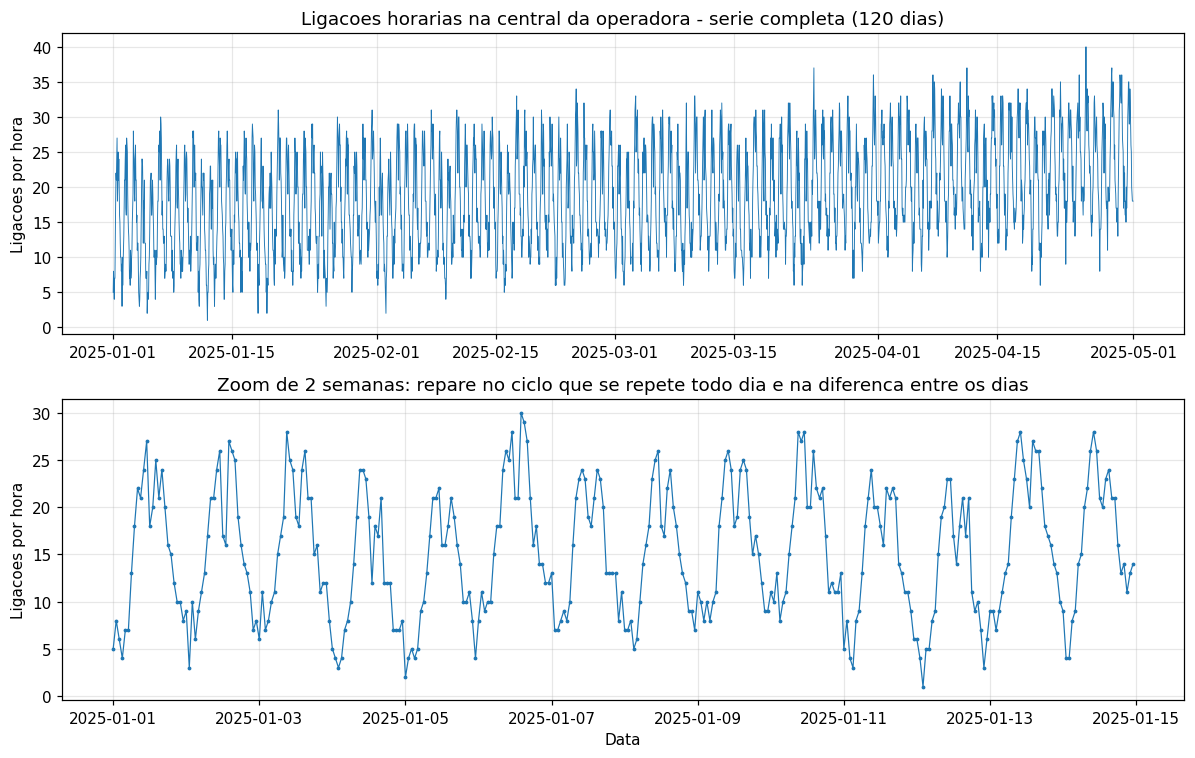

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))

# Serie completa (120 dias)
ax1.plot(ligacoes.index, ligacoes["n_ligacoes"], color="#1f77b4", lw=0.6)
ax1.set_title("Ligacoes horarias na central da operadora - serie completa (120 dias)")
ax1.set_ylabel("Ligacoes por hora")

# Zoom em 2 semanas para enxergar os ciclos diario e semanal
zoom = ligacoes.iloc[:14 * 24]
ax2.plot(zoom.index, zoom["n_ligacoes"], color="#1f77b4", marker=".", ms=3, lw=0.8)
ax2.set_title("Zoom de 2 semanas: repare no ciclo que se repete todo dia e na diferenca entre os dias")
ax2.set_ylabel("Ligacoes por hora"); ax2.set_xlabel("Data")

plt.tight_layout(); plt.show()


> **Lendo o gráfico.** O painel de cima mostra os 120 dias inteiros. À primeira vista parece uma faixa cheia, porque cada dia traz 24 pontos e o olho não separa hora a hora; ainda assim dá para notar que o nível médio **sobe suavemente da esquerda para a direita**, sinal da tendência de crescimento da carteira.
>
> O painel de baixo é um zoom de 2 semanas, e aqui os padrões ficam nítidos:
>
> - o **ciclo diário**: todo dia a curva sobe pela manhã, faz pico e desce à noite, repetindo a mesma forma 14 vezes seguidas;
> - o **ciclo semanal**: as ondas dos dias úteis são mais altas do que as dos fins de semana, criando um ritmo de 7 dias sobreposto ao ritmo de 24 horas.
>
> São exatamente esses dois ciclos que os modelos das próximas aulas vão precisar aprender.


## 2.1 O que é uma Série Temporal

Uma **série temporal** é uma sequência de observações de uma mesma variável, medidas em pontos sucessivos e igualmente espaçados no tempo:

$$ y_1,\; y_2,\; y_3,\; \ldots,\; y_t $$

O volume de ligações na central a cada hora, o número de teleconsultas solicitadas a cada dia ou a sinistralidade apurada a cada mês são todos exemplos de séries temporais na gestão da operadora.

O que diferencia uma série temporal de uma tabela de dados comum é a **dependência temporal**: o valor de agora tende a se parecer com os valores dos instantes anteriores. Em notação, queremos capturar uma relação do tipo

$$ y*t = f(y*{t-1},\, y\_{t-2},\, \ldots) + \varepsilon_t $$

em que $\varepsilon_t$ é a parte imprevisível. Se as observações fossem independentes (como jogar um dado a cada hora), o passado não ajudaria em nada a prever o futuro e não haveria o que modelar. É exatamente essa dependência que todo modelo de previsão tenta capturar e explorar.

O gráfico a seguir torna a dependência **visível**: no eixo horizontal colocamos o volume de cada hora e, no eixo vertical, o volume da hora seguinte. Se não houvesse dependência, veríamos uma nuvem sem forma. O que aparece é uma relação bem clara.


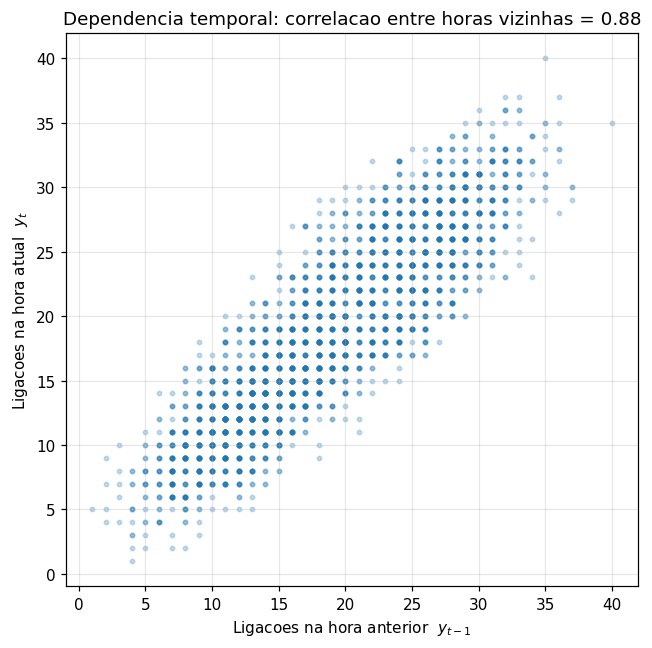

Correlacao entre o valor atual e o valor da hora anterior: 0.88
Quanto mais proximo de 1, mais o passado recente ajuda a prever o presente.


In [4]:
atual = ligacoes["n_ligacoes"]
anterior = atual.shift(1)
corr1 = atual.corr(anterior)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(anterior, atual, s=8, alpha=0.25, color="#1f77b4")
ax.set_xlabel(r"Ligacoes na hora anterior  $y_{t-1}$")
ax.set_ylabel(r"Ligacoes na hora atual  $y_t$")
ax.set_title(f"Dependencia temporal: correlacao entre horas vizinhas = {corr1:.2f}")
plt.tight_layout(); plt.show()

print(f"Correlacao entre o valor atual e o valor da hora anterior: {corr1:.2f}")
print("Quanto mais proximo de 1, mais o passado recente ajuda a prever o presente.")


> **Lendo o gráfico.** Cada ponto é uma hora: no eixo horizontal, o volume da hora anterior; no eixo vertical, o volume da hora seguinte. Os pontos formam uma **nuvem alongada na diagonal**, subindo da esquerda para a direita.
>
> Isso é a dependência temporal em imagem: horas com muitas ligações tendem a ser seguidas por horas com muitas ligações. O número que resume essa inclinação é a **correlação de 0,88** (numa escala de 0 a 1). Um valor tão alto confirma que o passado recente carrega muita informação sobre o presente, e é isso que torna a previsão possível. Se não houvesse dependência, a nuvem seria redonda e sem direção.


## 2.2 Os Quatro Componentes de uma Série Temporal

Toda série temporal pode ser entendida, de forma didática, como a combinação de quatro componentes:

| Componente          | Símbolo | O que é                                                | Exemplo na operadora                                                                                |
| ------------------- | ------- | ------------------------------------------------------ | --------------------------------------------------------------------------------------------------- |
| **Tendência**       | $T_t$   | movimento de longo prazo (sobe, desce ou estável)      | crescimento da carteira de beneficiários ao longo dos anos, que puxa o volume de contatos para cima |
| **Sazonalidade**    | $S_t$   | padrão que se repete em intervalo **fixo** e conhecido | o ciclo de 24 h da central (horário comercial) e o ciclo de 7 dias da semana                        |
| **Ciclo**           | $C_t$   | padrão que se repete, mas em intervalo **não fixo**    | ondas epidemiológicas (surtos de gripe elevam ligações e teleconsultas) e ciclos econômicos         |
| **Resíduo / ruído** | $R_t$   | o que sobra depois de remover os três anteriores       | variação aleatória que nenhum modelo determinístico explica                                         |

Existem duas formas clássicas de combinar esses componentes:

$$ \underbrace{y*t = T_t + S_t + C_t + R_t}*{\text{modelo aditivo}} \qquad\qquad \underbrace{y*t = T_t \times S_t \times C_t \times R_t}*{\text{modelo multiplicativo}} $$

Usamos o **modelo aditivo** quando a amplitude da sazonalidade é mais ou menos constante ao longo do tempo, e o **multiplicativo** quando a sazonalidade cresce junto com o nível da série. Prever nada mais é do que estimar de forma sistemática os três primeiros componentes e tratar o quarto como incerteza. Hyndman e Athanasopoulos (2021) chamam esse processo de **decomposição** da série, e ele é, na prática, o primeiro passo de qualquer análise antes de escolher um modelo.

A função `seasonal_decompose` do `statsmodels` faz essa separação automaticamente. Usamos `period=24` porque a série é horária e o ciclo diário tem 24 pontos.


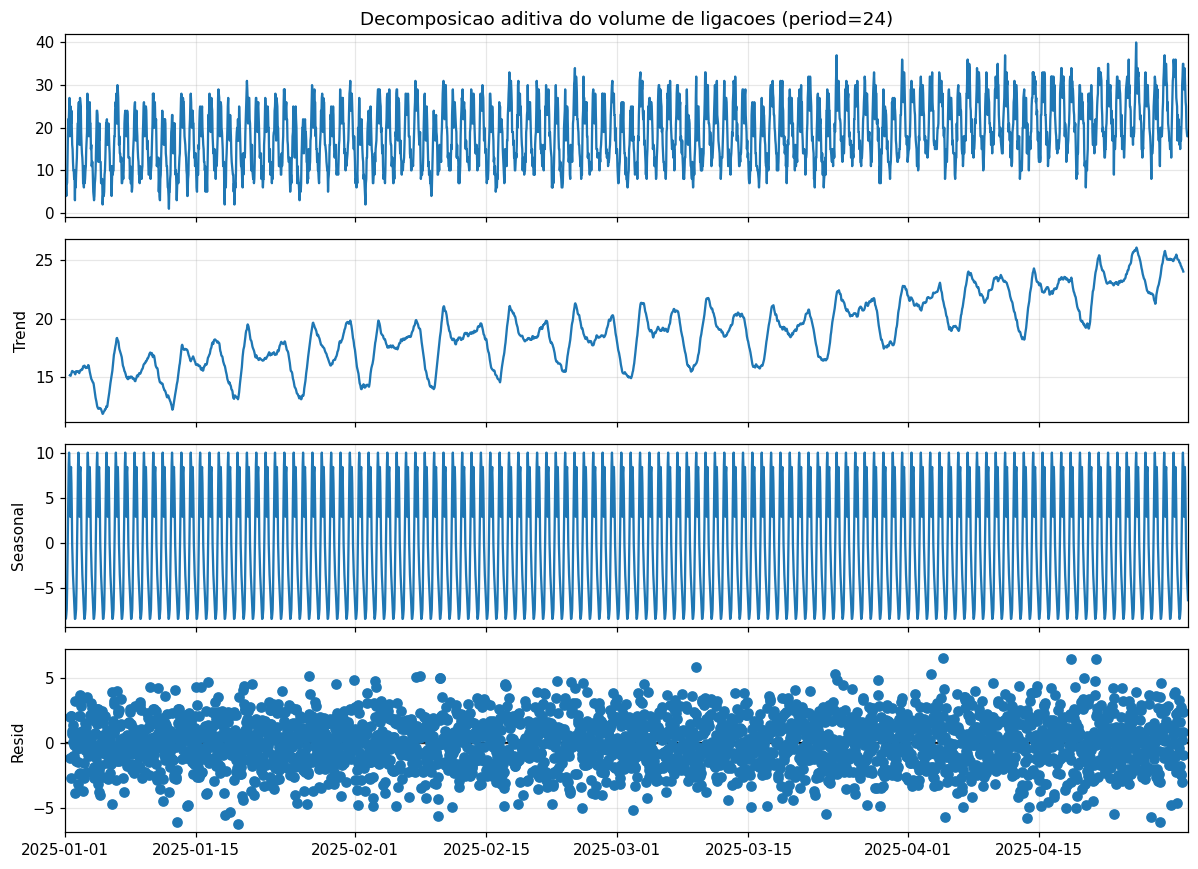

De cima para baixo: serie original, Tendencia (T), Sazonalidade diaria (S) e Residuo (R).


In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

resultado = seasonal_decompose(ligacoes["n_ligacoes"], model="additive", period=24)

fig = resultado.plot()
fig.set_size_inches(11, 8)
for ax in fig.axes:
    ax.grid(True, alpha=0.3)
fig.axes[0].set_title("Decomposicao aditiva do volume de ligacoes (period=24)")
plt.tight_layout(); plt.show()

print("De cima para baixo: serie original, Tendencia (T), Sazonalidade diaria (S) e Residuo (R).")


> **Lendo o gráfico.** A `seasonal_decompose` separou a série em quatro faixas empilhadas:
>
> - **Observado** (topo): a série original, com todos os componentes juntos.
> - **Trend** (tendência): uma linha que sobe de cerca de **15 para cerca de 24** ligações por hora ao longo dos 120 dias. É o crescimento de longo prazo isolado.
> - **Seasonal** (sazonalidade): o ciclo diário que se repete, com amplitude de cerca de **18 ligações** entre o vale da madrugada (perto de -8 em torno da média) e o pico do dia (perto de +10).
> - **Resid** (resíduo): o que sobrou depois de remover tendência e sazonalidade, uma faixa estreita de ruído com desvio-padrão de apenas cerca de **1,9**.
>
> A lição é que quase toda a variação da série é explicada por tendência mais sazonalidade; o resíduo pequeno mostra que restou pouca aleatoriedade pura. É por isso que essa série é tão previsível.


### Enxergando a sazonalidade de perto

A decomposição acima isolou o ciclo de 24 horas. Mas a nossa série tem, na verdade, **duas** sazonalidades sobrepostas: a diária e a semanal. Uma forma direta de visualizar cada uma é calcular a média de ligações por hora do dia e por dia da semana. Esses perfis são o retrato da rotina da central e serão exatamente o que os modelos vão tentar reproduzir. Para o gestor, esse é o mapa de quando alocar mais atendentes.


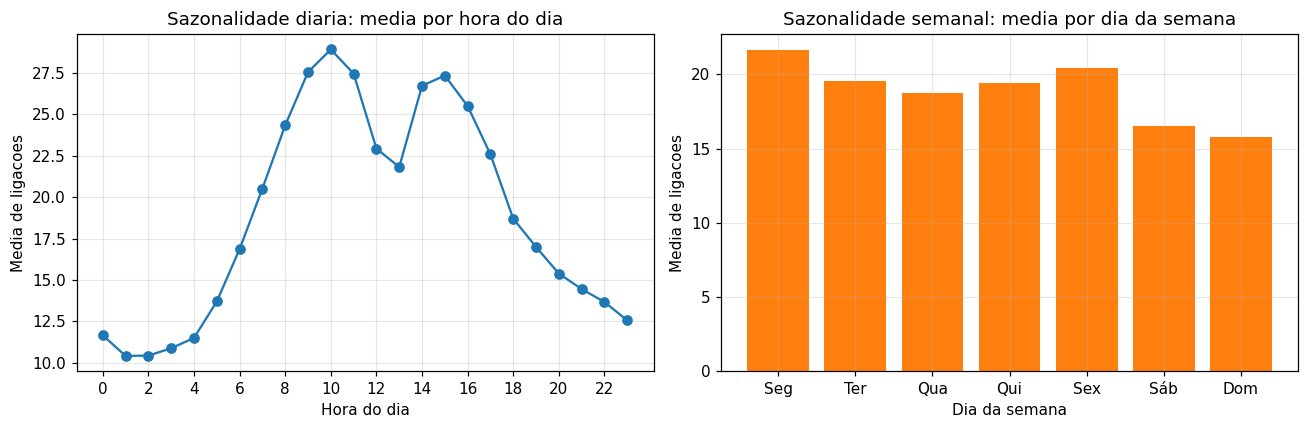

Hora de maior volume: 10h (28.9 ligacoes/h)
Hora de menor volume: 1h (10.4 ligacoes/h)


In [6]:
perfil_hora = ligacoes.groupby(ligacoes.index.hour)["n_ligacoes"].mean()
perfil_dia = ligacoes.groupby(ligacoes.index.dayofweek)["n_ligacoes"].mean()
nomes_dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(perfil_hora.index, perfil_hora.values, marker="o", color="#1f77b4")
ax1.set_title("Sazonalidade diaria: media por hora do dia")
ax1.set_xlabel("Hora do dia"); ax1.set_ylabel("Media de ligacoes")
ax1.set_xticks(range(0, 24, 2))

ax2.bar(range(7), perfil_dia.values, color="#ff7f0e")
ax2.set_title("Sazonalidade semanal: media por dia da semana")
ax2.set_xlabel("Dia da semana"); ax2.set_ylabel("Media de ligacoes")
ax2.set_xticks(range(7)); ax2.set_xticklabels(nomes_dias)

plt.tight_layout(); plt.show()

print(f"Hora de maior volume: {perfil_hora.idxmax()}h ({perfil_hora.max():.1f} ligacoes/h)")
print(f"Hora de menor volume: {perfil_hora.idxmin()}h ({perfil_hora.min():.1f} ligacoes/h)")


> **Lendo os gráficos.** À esquerda, a média por hora do dia desenha o retrato de um call center: vale de madrugada (mínimo de **10,4 ligações/h por volta de 1h**), forte subida pela manhã até o **pico de 28,9 ligações/h às 10h**, uma queda no horário de almoço e um segundo platô à tarde. À direita, a média por dia da semana mostra o ciclo semanal: **segunda-feira é o dia mais cheio (21,6)** e o volume cai ao longo da semana até o **domingo, o mais calmo (15,8)**.
>
> Para o gestor, esses dois perfis são o mapa de escala: dizem em que horas e em que dias colocar mais atendentes. Para o modelo, são a sazonalidade que ele precisa reproduzir.


### Laboratório interativo: sinta cada componente

Nada fixa melhor a ideia dos quatro componentes do que mexer neles. Nos controles abaixo:

- **Tendência**: quanto a série cresce por dia. Zero deixa o nível estável; valores altos criam uma rampa de crescimento (imagine uma campanha que amplia a carteira).
- **Amp. diária**: o tamanho do ciclo de 24 h. Em zero, dia e madrugada ficam iguais.
- **Amp. semanal**: o tamanho do ciclo de 7 dias (diferença entre segunda e domingo).
- **Ruído**: a intensidade da parte aleatória.

Mova os controles e observe as duas semanas de série se transformarem. Tente, por exemplo, zerar a amplitude diária e ver como o padrão desaparece, ou aumentar o ruído até o sinal quase sumir.

> Se os controles não aparecerem no seu ambiente, a célula mostra automaticamente uma versão estática com os valores padrão.


In [ ]:
try:
    from ipywidgets import interact, FloatSlider
    _INTERATIVO = True
except ImportError:
    _INTERATIVO = False

def laboratorio_componentes(tendencia=0.06, amp_diaria=1.0, amp_semanal=1.0, ruido=1.8):
    serie = gerar_serie_ligacoes(tendencia=tendencia, amp_diaria=amp_diaria,
                                 amp_semanal=amp_semanal, ruido=ruido)
    duas_semanas = serie.iloc[:14 * 24]
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(duas_semanas.index, duas_semanas["n_ligacoes"], color="#1f77b4", marker=".", ms=3, lw=0.8)
    ax.set_title("Ligacoes na central (2 semanas) com os componentes que voce escolheu")
    ax.set_xlabel("Data"); ax.set_ylabel("Ligacoes por hora")
    ax.set_ylim(0, 45)
    plt.tight_layout(); plt.show()

if _INTERATIVO:
    interact(
        laboratorio_componentes,
        tendencia=FloatSlider(value=0.06, min=-0.2, max=0.5, step=0.02, description="Tendência"),
        amp_diaria=FloatSlider(value=1.0, min=0.0, max=2.5, step=0.1, description="Amp. diária"),
        amp_semanal=FloatSlider(value=1.0, min=0.0, max=3.0, step=0.1, description="Amp. semanal"),
        ruido=FloatSlider(value=1.8, min=0.0, max=6.0, step=0.2, description="Ruído"),
    )
else:
    print("ipywidgets indisponivel; exibindo a versao estatica com os valores padrao.")
    laboratorio_componentes()


interactive(children=(FloatSlider(value=0.06, description='Tendência', max=0.5, min=-0.2, step=0.02), FloatSli…

> **O que observar.** Com os valores padrão, o gráfico reproduz as 2 semanas típicas da central. Use os controles como um experimento controlado: ao **zerar a amplitude diária**, as ondas de 24 horas somem e sobra apenas o degrau entre semana e fim de semana; ao **aumentar o ruído**, a forma regular vai se dissolvendo dentro da aleatoriedade; ao **subir a tendência**, a série ganha uma rampa de crescimento visível. É a maneira mais direta de sentir o peso de cada componente separadamente.


## 2.3 Estacionariedade

> **Definição formal.** Uma série temporal é dita **estacionária** quando suas propriedades estatísticas (média, variância e estrutura de autocorrelação) **não mudam ao longo do tempo**. Em termos práticos: uma série estacionária oscila em torno de um nível constante, sem tendência de longo prazo e sem sazonalidade não removida.

Formalmente, esperamos que, para qualquer instante $t$,

$$ \mathbb{E}[y_t] = \mu \quad (\text{média constante}) \qquad\qquad \mathrm{Var}(y_t) = \sigma^2 \quad (\text{variância constante}) $$

Por que isso importa tanto? Porque a estacionariedade é o **pressuposto central** dos modelos ARIMA (Seção 3): os componentes AR e MA só têm interpretação estatística válida quando aplicados a uma série estacionária. As séries da operadora quase nunca são estacionárias no estado bruto, pois têm sazonalidade forte e, muitas vezes, uma tendência de crescimento ligada ao aumento da base de beneficiários.

A ferramenta para deixar uma série estacionária é a **diferenciação**: em vez de modelar o valor, modelamos a _variação_ de um período para o outro.

$$ \nabla y*t = y_t - y*{t-1} \qquad (\text{primeira diferença}) $$

Essa operação remove a tendência e corresponde exatamente ao componente **I (integrado)** do ARIMA, o "d" da sigla. Existe também a **diferença sazonal**, $\nabla_s y_t = y_t - y_{t-s}$, que remove um ciclo de tamanho $s$ (por exemplo, $s = 24$ para o ciclo diário, ou $s = 7$ para o semanal).

Para enxergar a tendência de longo prazo sem o vaivém do ciclo intradiário, é conveniente olhar a série **agregada por dia** (total de ligações por dia). A média móvel deixa a não estacionariedade evidente: ela sobe ao longo do tempo em vez de ficar plana.


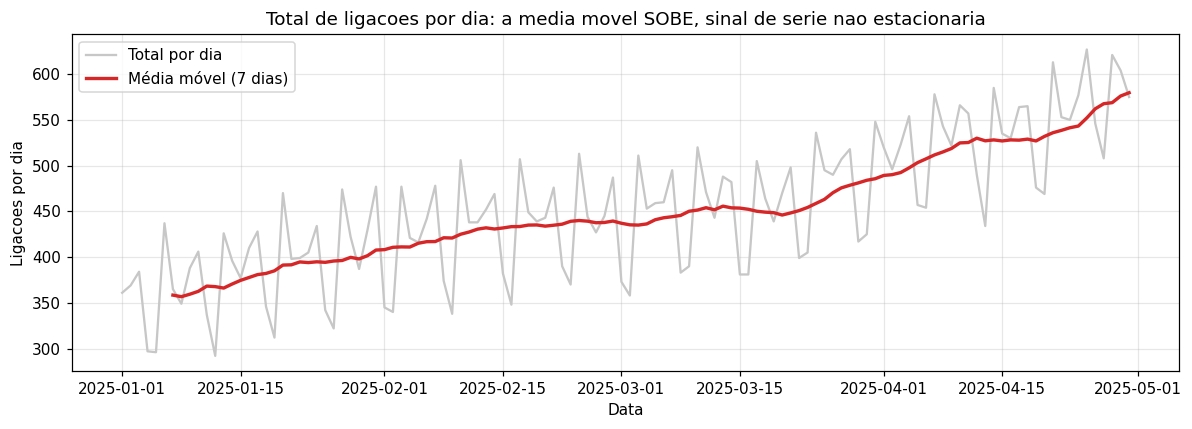

In [8]:
ligacoes_diarias = ligacoes["n_ligacoes"].resample("D").sum()
media_movel = ligacoes_diarias.rolling(7).mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ligacoes_diarias.index, ligacoes_diarias.values, color="#c7c7c7", label="Total por dia")
ax.plot(media_movel.index, media_movel.values, color="#d62728", lw=2.2, label="Média móvel (7 dias)")
ax.set_title("Total de ligacoes por dia: a media movel SOBE, sinal de serie nao estacionaria")
ax.set_xlabel("Data"); ax.set_ylabel("Ligacoes por dia"); ax.legend()
plt.tight_layout(); plt.show()


> **Lendo o gráfico.** Agora somamos as ligações de cada dia (por isso os valores estão na casa das centenas). A linha cinza é o total diário e a linha vermelha é a **média móvel de 7 dias**, que suaviza o vaivém da semana para revelar a tendência.
>
> O ponto central: a média móvel **não é plana, ela sobe** de forma consistente (o total típico passa de cerca de **358 ligações na primeira semana para cerca de 580 na última**, um crescimento de mais de 60%). Uma série cuja média muda ao longo do tempo é, por definição, **não estacionária**. O teste a seguir confirma isso com um número objetivo.


### O teste de Dickey-Fuller Aumentado (ADF)

Olhar o gráfico ajuda, mas a estacionariedade é verificada de forma objetiva com um teste estatístico. O mais usado é o **teste de Dickey-Fuller Aumentado (ADF)**, disponível no `statsmodels`. A lógica das hipóteses é:

- **Hipótese nula ($H_0$):** a série **não** é estacionária (possui raiz unitária).
- **Hipótese alternativa ($H_1$):** a série é estacionária.

A regra de decisão usa o **p-valor**: se ele for menor que 0,05, rejeitamos $H_0$ e concluímos que a série é estacionária. A célula abaixo aplica o teste na série diária original e, em seguida, na sua primeira diferença, deixando o próprio código anunciar o veredito.


In [9]:
from statsmodels.tsa.stattools import adfuller

def testar_estacionariedade(serie, nome):
    resultado = adfuller(serie.dropna().values)
    estatistica, p_valor = resultado[0], resultado[1]
    if p_valor < 0.05:
        veredito = "ESTACIONARIA (rejeita H0)"
    else:
        veredito = "NAO estacionaria (nao rejeita H0)"
    print(f"{nome}")
    print(f"  Estatistica ADF: {estatistica:8.3f}")
    print(f"  p-valor:         {p_valor:8.4f}   ->  {veredito}")
    print()

testar_estacionariedade(ligacoes_diarias, "Serie diaria ORIGINAL")
testar_estacionariedade(ligacoes_diarias.diff(), "Serie diaria apos a 1a DIFERENCA")


Serie diaria ORIGINAL
  Estatistica ADF:    1.533
  p-valor:           0.9976   ->  NAO estacionaria (nao rejeita H0)

Serie diaria apos a 1a DIFERENCA
  Estatistica ADF:   -4.431
  p-valor:           0.0003   ->  ESTACIONARIA (rejeita H0)



> **Lendo a tabela.** O teste ADF devolve um p-valor, e a regra é simples: **p abaixo de 0,05 indica série estacionária**.
>
> - **Série original**: p-valor de **0,9976**, altíssimo. Não rejeitamos a hipótese de não estacionariedade, ou seja, a série **não é estacionária**, confirmando com estatística a subida da média móvel que acabamos de ver.
> - **Após 1 diferença**: p-valor de **0,0003**, bem abaixo de 0,05. Agora a série **é estacionária** (a estatística ADF também fica bem negativa, -4,43).
>
> Conclusão prática: **uma única diferenciação basta** para estabilizar esta série. Guarde este resultado, pois ele é exatamente o parâmetro $d = 1$ que usaremos no ARIMA na próxima aula.


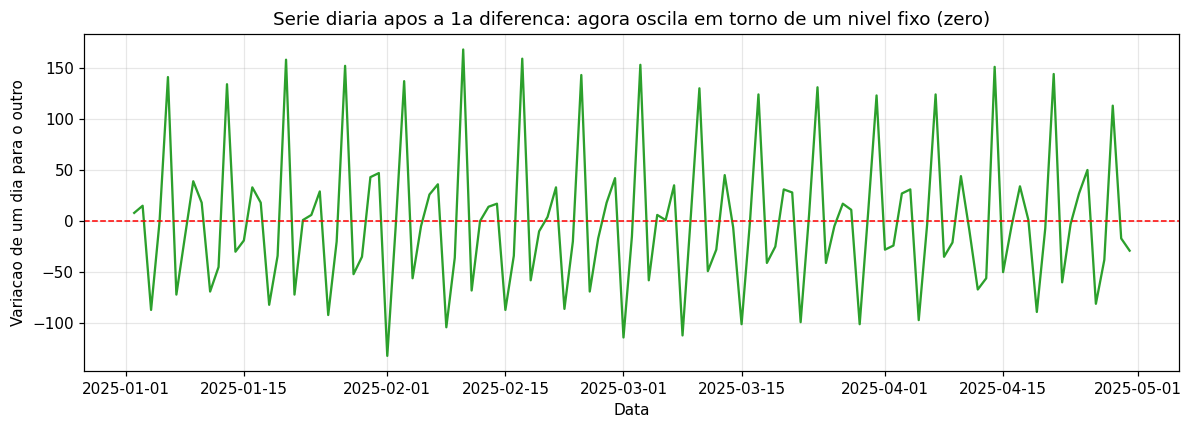

In [10]:
diferenciada = ligacoes_diarias.diff().dropna()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(diferenciada.index, diferenciada.values, color="#2ca02c")
ax.axhline(0, color="red", ls="--", lw=1)
ax.set_title("Serie diaria apos a 1a diferenca: agora oscila em torno de um nivel fixo (zero)")
ax.set_xlabel("Data"); ax.set_ylabel("Variacao de um dia para o outro")
plt.tight_layout(); plt.show()


> **Lendo o gráfico.** Esta é a série depois de subtrair de cada dia o valor do dia anterior, ou seja, a _variação_ diária. Repare que ela agora **oscila em torno de zero** (a linha vermelha), dentro de uma faixa de amplitude aproximadamente constante, sem subir nem descer no longo prazo. Esse é o retrato visual de uma série estacionária: foi justamente esta transformação que derrubou o p-valor do ADF de 0,9976 para 0,0003.


### Laboratório interativo: o efeito da diferenciação

Escolha a transformação no menu e compare. Observe como a série original vive acima de uma média que sobe, enquanto a série diferenciada se aquieta em torno de zero. O título do gráfico mostra o p-valor do ADF e o veredito correspondente a cada escolha, para você conectar o que o olho vê com o que o teste conclui.


In [ ]:
try:
    from ipywidgets import interact, Dropdown
    _INTERATIVO2 = True
except ImportError:
    _INTERATIVO2 = False

def explorar_estacionariedade(transformacao="Série original"):
    if transformacao == "Série original":
        y = ligacoes_diarias
    else:
        y = ligacoes_diarias.diff().dropna()
    p = adfuller(y.dropna().values)[1]
    veredito = "ESTACIONARIA" if p < 0.05 else "NAO estacionaria"
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(y.index, y.values, color="#2ca02c")
    ax.axhline(y.mean(), color="red", ls="--", lw=1, label=f"media = {y.mean():.0f}")
    ax.set_title(f"{transformacao}   |   ADF p-valor = {p:.4f}   ->   {veredito}")
    ax.set_xlabel("Data"); ax.set_ylabel("Ligacoes por dia"); ax.legend()
    plt.tight_layout(); plt.show()

if _INTERATIVO2:
    interact(
        explorar_estacionariedade,
        transformacao=Dropdown(options=["Série original", "1a diferença"],
                               value="Série original", description="Transformação"),
    )
else:
    print("ipywidgets indisponivel; exibindo as duas transformacoes de forma estatica.")
    explorar_estacionariedade("Série original")
    explorar_estacionariedade("1a diferença")


interactive(children=(Dropdown(description='Transformação', options=('Série original', '1a diferença'), value=…

> **O que observar.** Na opção padrão, "Série original", o título mostra o p-valor alto e o veredito de não estacionária, e a linha vermelha da média fica bem acima do começo da série. Troque para "1a diferença" e veja duas coisas ao mesmo tempo: a curva se achata em torno de zero **e** o p-valor no título cai para baixo de 0,05, mudando o veredito para estacionária. É a conexão direta entre o que o olho vê e o que o teste conclui.


## 2.4 Autocorrelação: ACF e PACF

A **autocorrelação** mede o quanto o valor da série em um instante se parece com o valor da própria série em instantes anteriores, os chamados **lags** (defasagens). O coeficiente de autocorrelação no lag $k$ é

$$ r*k = \frac{\sum*{t=k+1}^{n} (y*t - \bar{y})(y*{t-k} - \bar{y})}{\sum\_{t=1}^{n} (y_t - \bar{y})^2} $$

Duas funções resumem essa relação e orientam diretamente a escolha dos parâmetros do ARIMA:

- **ACF (Autocorrelation Function):** correlação entre a série e ela mesma defasada em $k$ períodos, **incluindo** os efeitos indiretos que passam pelas defasagens intermediárias. Um pico na ACF no lag 24, numa série horária, denuncia a repetição a cada 24 horas.
- **PACF (Partial Autocorrelation Function):** a mesma correlação, mas **removendo** o efeito das defasagens intermediárias, isolando a relação direta entre o valor atual e o valor $k$ períodos atrás.

Na metodologia de **Box-Jenkins** (Box e Jenkins, 1970), a leitura visual desses gráficos guia a identificação do modelo:

- um **corte abrupto na PACF** depois do lag $p$ sugere um componente **AR($p$)**;
- um **corte abrupto na ACF** depois do lag $q$ sugere um componente **MA($q$)**.

Nos gráficos abaixo, repare especialmente nos lags 24 e 48: os picos ali são a assinatura inconfundível do ciclo diário da central. A faixa azul sombreada é o intervalo de confiança: barras que ultrapassam essa faixa indicam autocorrelação estatisticamente relevante.


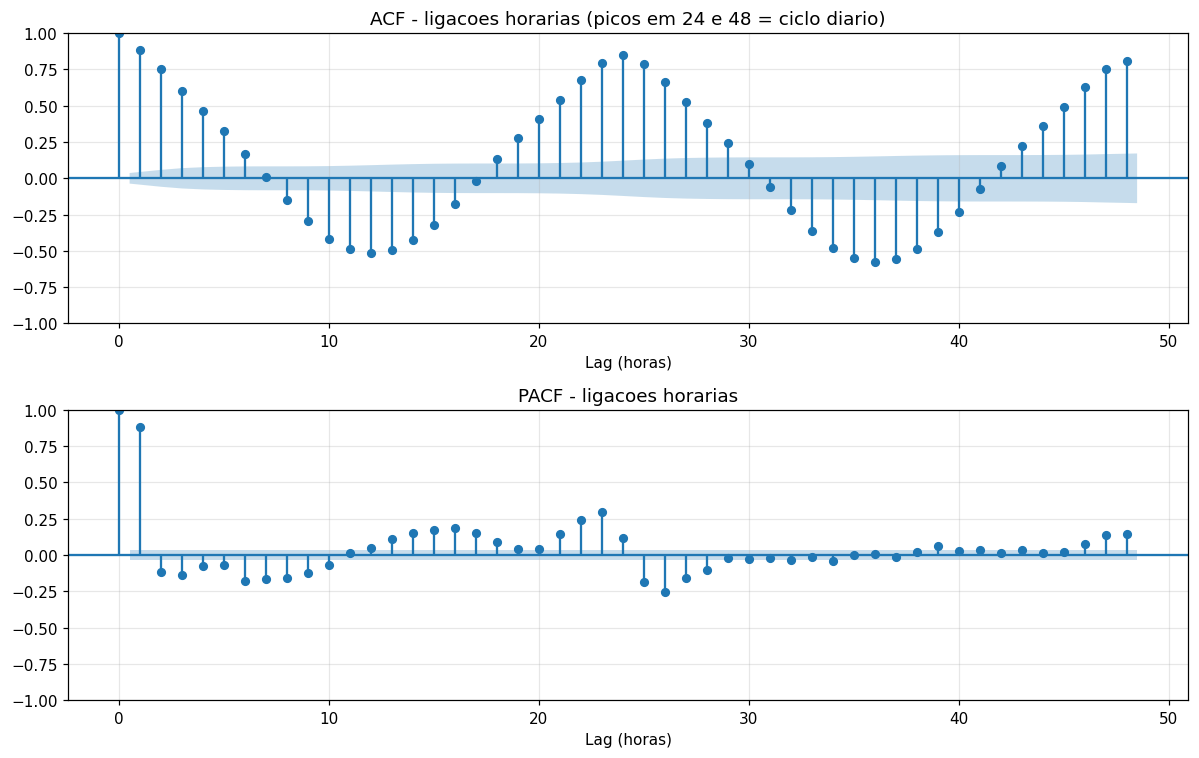

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))

plot_acf(ligacoes["n_ligacoes"], lags=48, ax=ax1)
plot_pacf(ligacoes["n_ligacoes"], lags=48, ax=ax2, method="ywm")

ax1.set_title("ACF - ligacoes horarias (picos em 24 e 48 = ciclo diario)")
ax2.set_title("PACF - ligacoes horarias")
ax1.set_xlabel("Lag (horas)"); ax2.set_xlabel("Lag (horas)")

plt.tight_layout(); plt.show()


> **Lendo os gráficos.** Cada barra é a correlação da série com ela mesma defasada por aquele número de horas; a faixa azul é o intervalo de confiança (barras dentro dela são compatíveis com ruído).
>
> - Na **ACF** (topo), as barras decaem devagar e formam **picos que se destacam nos lags 24 e 48** (valores de cerca de **0,85 e 0,81**). Essa repetição a cada 24 horas é a assinatura da sazonalidade diária.
> - Na **PACF** (base), há um **pico forte no lag 1 (0,88)** e, logo depois, as barras despencam para perto de zero. Esse corte abrupto após o primeiro lag é a pista clássica de que um componente autorregressivo de ordem baixa já captura boa parte da estrutura.
>
> Na próxima aula, essa leitura orienta diretamente a escolha das ordens $q$ (pela ACF) e $p$ (pela PACF) do ARIMA.


## Síntese e conexão com os próximos módulos

Você acabou de percorrer o vocabulário que sustenta todos os modelos de previsão do curso. Vale guardar este mapa:

| Conceito             | O que mede                                       | Uso principal nesta aula                                                       |
| -------------------- | ------------------------------------------------ | ------------------------------------------------------------------------------ |
| **Tendência**        | movimento de longo prazo da série                | componente $g(t)$ do Prophet (Seção 4); diferenciação ($d$) do ARIMA (Seção 3) |
| **Sazonalidade**     | padrão que se repete em ciclo fixo               | componente sazonal $(P, D, Q, s)$ do SARIMA; componente $s(t)$ do Prophet      |
| **Estacionariedade** | estabilidade da média e da variância no tempo    | pré-requisito estatístico do ARIMA / SARIMA                                    |
| **ACF**              | correlação da série com seus próprios lags       | identificação da ordem $q$ (MA) do ARIMA                                       |
| **PACF**             | correlação direta da série com um lag específico | identificação da ordem $p$ (AR) do ARIMA                                       |

**Onde cada fundamento aparece na gestão da operadora:** os mesmos conceitos que praticamos com o volume de ligações valem para as outras séries da operação, todas tratadas na Seção 14:

- **Volume de ligações no call center**: sazonalidade diária e semanal forte, usada para dimensionar a escala de atendentes.
- **Demanda por teleconsulta**: tendência de crescimento somada a ondas epidemiológicas (o componente de ciclo).
- **Sinistralidade mensal**: série de baixa frequência, com sazonalidade anual e tendência, foco em controle de custo.
- **Solicitações de autorização prévia**: forte sazonalidade semanal, ligada ao fluxo administrativo.

**Para onde vamos a partir daqui:**

- A **tendência** que aprendemos a enxergar vira o parâmetro $d$ do ARIMA e o termo de crescimento do Prophet.
- A **sazonalidade** diária e semanal vira a parte sazonal $(P, D, Q, s)$ do SARIMA.
- A **estacionariedade** e a **diferenciação** são o pré-processamento obrigatório antes de qualquer ARIMA.
- A leitura de **ACF** e **PACF** é o mapa para escolher $p$ e $q$ na próxima aula.

Dominado o alfabeto, na Seção 3 passamos a formar as primeiras palavras: o modelo ARIMA.

---

**Referências**

- Hyndman, R. J.; Athanasopoulos, G. _Forecasting: Principles and Practice_. 3ª edição, 2021.
- Box, G. E. P.; Jenkins, G. M. _Time Series Analysis: Forecasting and Control_. 1970.
